In [1]:
import cooler
import cooltools
import bioframe as bf
import bbi
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ggner_3d.cm import CLR_CONNS, get_expected_cis_df, prepare_view_df
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score
from ggner_3d.dots_common import compare_loops_with_strength
from ggner_3d.bbi_helpers import stackup_bw_dict, stackup_bw_dict_q
from ggner_3d import plotting
from ggner_3d.plotting import plot_flanks_start_end_stackup, lineplot_stackup_dict
plotting.update_rcparams()

NPROC = 6
resolution = 10000
window = 500_000
clr_ = CLR_CONNS(resolution)
clustering_radius = 20_000

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

all_samples = list(clr_.keys())

In [2]:
dots_dfs_ = [
    pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/dots/dots_{s}_{resolution}.csv') for s in all_samples
]

Anchors counts: [14384, 3595, 3996]
Loops counts: [10869, 3752, 4184]


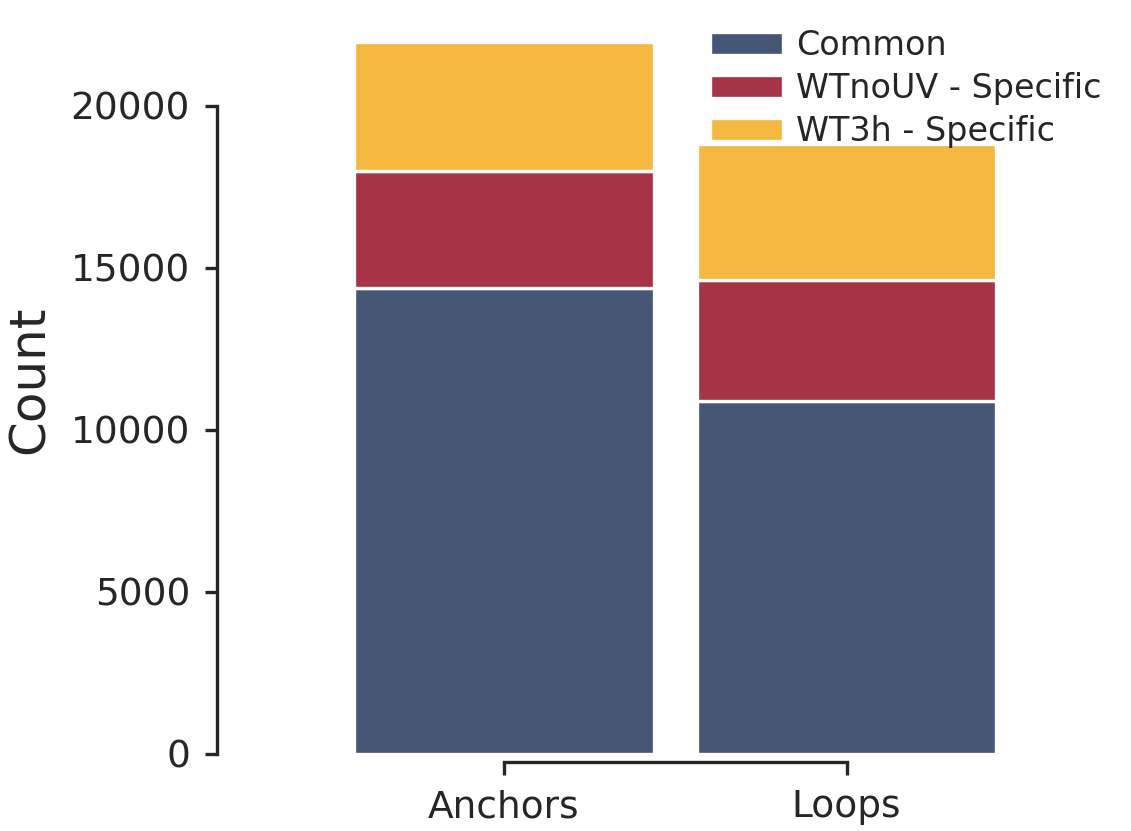

In [4]:
from ggner_3d.loop_helpers import plot_anchor_loop_counts

from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(4, 3))

plot_anchor_loop_counts(
    s1='WTnoUV',
    s2='WT3h',
    clr_=clr_,
    dots_dfs_=dots_dfs_,
    clustering_radius=clustering_radius,
    plotting=plotting,
    compute_strength=False,
    ax=ax
)

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig1/anchor_loop_counts_wt.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig1/anchor_loop_counts_wt.svg', bbox_inches='tight')